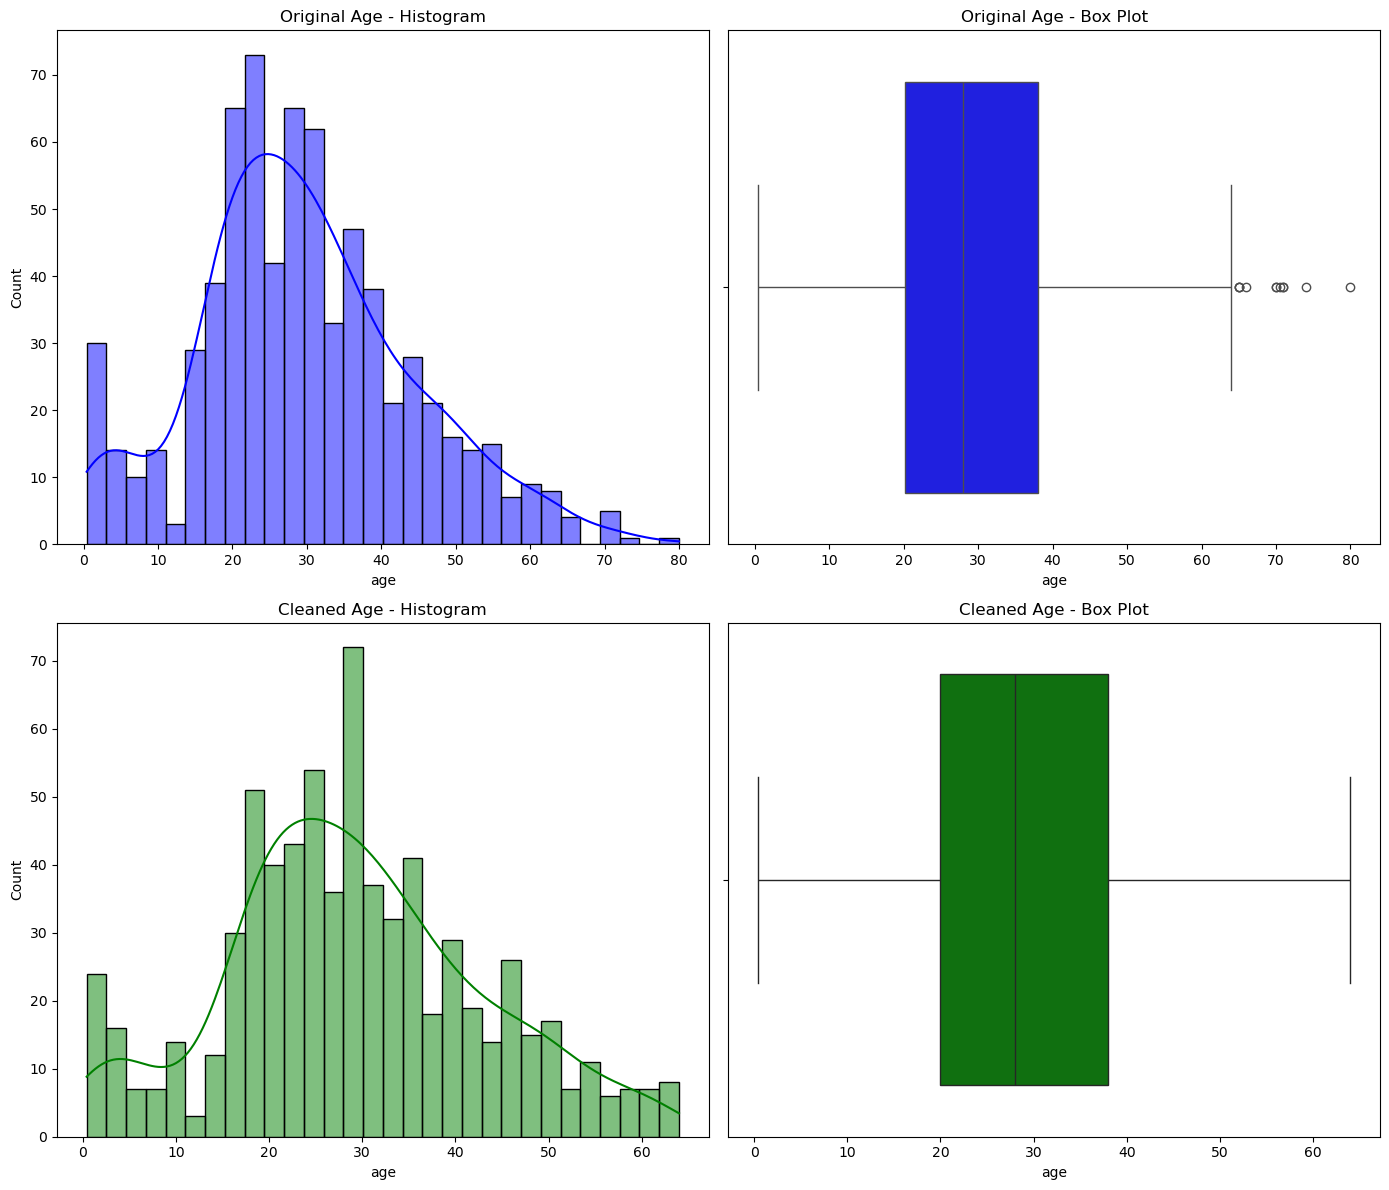

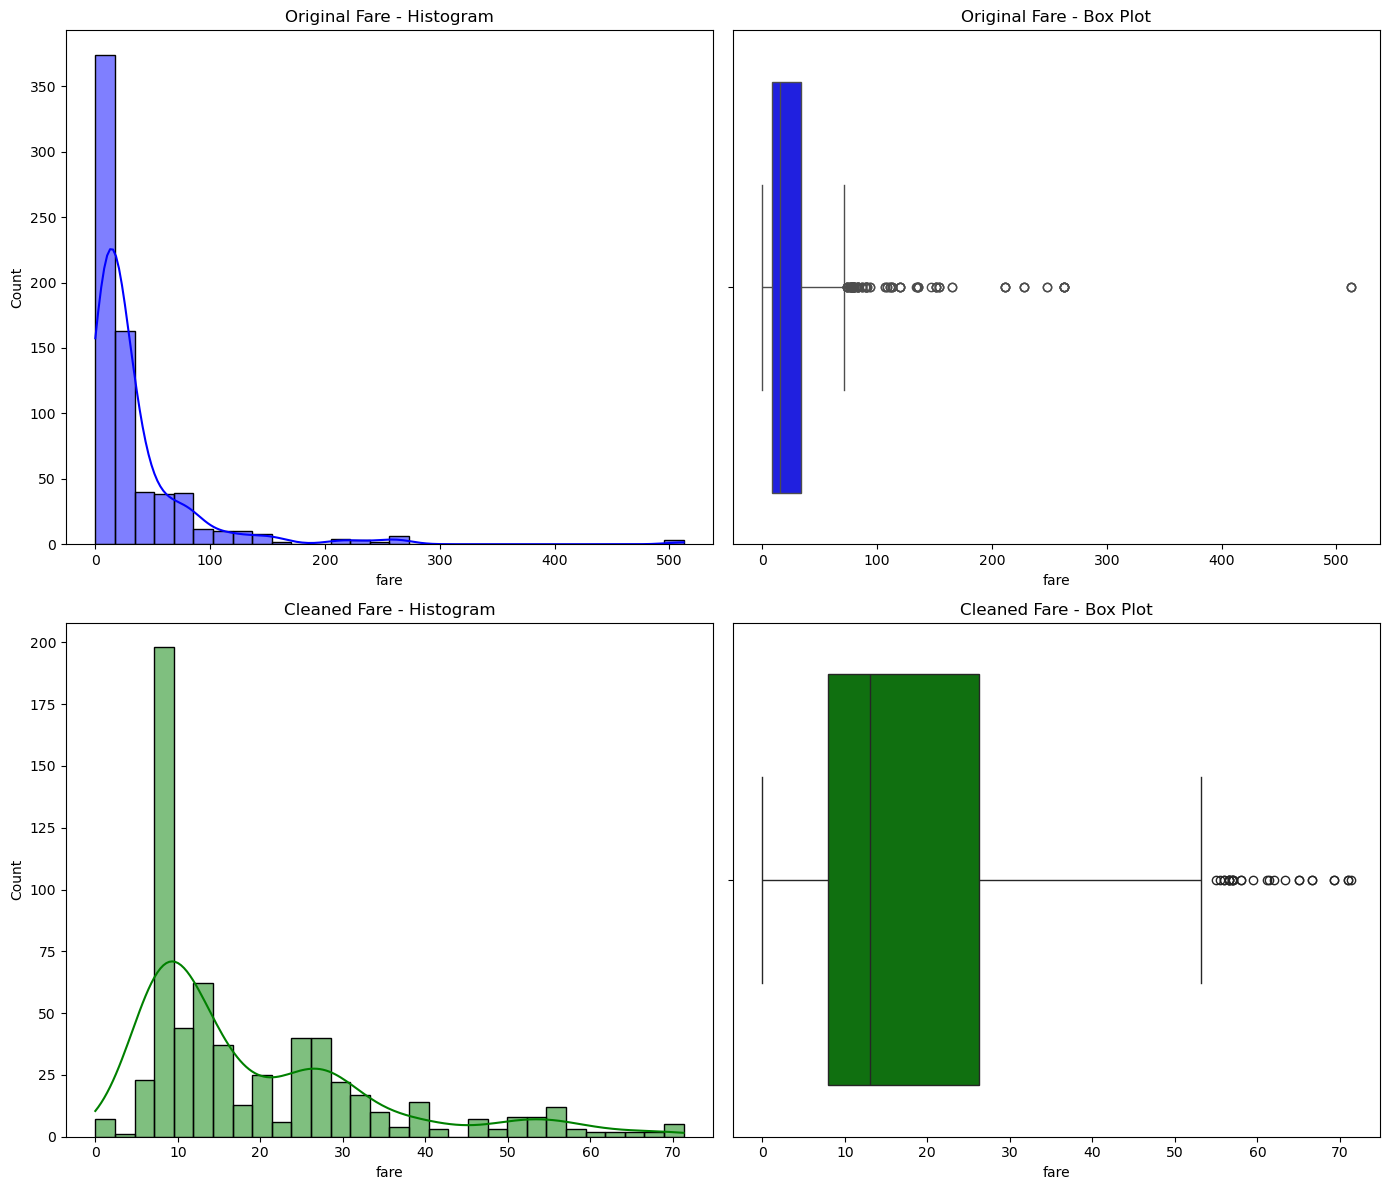

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = sns.load_dataset('titanic')

df = df.dropna(subset=['age', 'fare'])

def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_filtered = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df_filtered

df_age_cleaned = remove_outliers(df, 'age')
df_fare_cleaned = remove_outliers(df, 'fare')

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

sns.histplot(df['age'], bins=30, kde=True, ax=axes[0, 0], color='blue')
axes[0, 0].set_title('Original Age - Histogram')

sns.boxplot(x=df['age'], ax=axes[0, 1], color='blue')
axes[0, 1].set_title('Original Age - Box Plot')

sns.histplot(df_age_cleaned['age'], bins=30, kde=True, ax=axes[1, 0], color='green')
axes[1, 0].set_title('Cleaned Age - Histogram')

sns.boxplot(x=df_age_cleaned['age'], ax=axes[1, 1], color='green')
axes[1, 1].set_title('Cleaned Age - Box Plot')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

sns.histplot(df['fare'], bins=30, kde=True, ax=axes[0, 0], color='blue')
axes[0, 0].set_title('Original Fare - Histogram')

sns.boxplot(x=df['fare'], ax=axes[0, 1], color='blue')
axes[0, 1].set_title('Original Fare - Box Plot')

sns.histplot(df_fare_cleaned['fare'], bins=30, kde=True, ax=axes[1, 0], color='green')
axes[1, 0].set_title('Cleaned Fare - Histogram')

sns.boxplot(x=df_fare_cleaned['fare'], ax=axes[1, 1], color='green')
axes[1, 1].set_title('Cleaned Fare - Box Plot')

plt.tight_layout()
plt.show()
